In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr

Common utility functions

In [ ]:
def display_ordered_distribution(
    df,
    factor_col,
    expected_scores=None,
    model_name=None,
    xlabel=None,
    title=None,
    numeric=True,
    figsize=(6, 4)
):
    """
    有序カテゴリ変数の分布を確認する。
    例: Clarity, Artifact, Field definition
    """
    tmp = df[[factor_col]].copy()

    if numeric:
        tmp[factor_col] = pd.to_numeric(tmp[factor_col], errors="coerce")

    print("Total rows:", len(tmp))
    print(f"Missing {factor_col}:", tmp[factor_col].isna().sum())
    print(f"Unique {factor_col} values:")
    print(sorted(tmp[factor_col].dropna().unique()))

    if expected_scores is not None:
        observed_scores = set(tmp[factor_col].dropna().astype(int).unique())
        unexpected_scores = sorted(observed_scores - set(expected_scores))
        print("Unexpected scores:", unexpected_scores if unexpected_scores else "None")

    dist_df = (
        tmp[factor_col]
        .value_counts(dropna=False)
        .rename_axis(factor_col)
        .reset_index(name="count")
    )

    # NaN を最後に並べる
    dist_df["sort_key"] = dist_df[factor_col].fillna(999999)
    dist_df = dist_df.sort_values("sort_key").drop(columns="sort_key")

    dist_df["ratio_%"] = (dist_df["count"] / len(tmp) * 100).round(2)

    display(dist_df)

    print(f"{factor_col} summary:")
    display(tmp[factor_col].describe().to_frame().T)

    # bar plot
    plot_df = dist_df[dist_df[factor_col].notna()].copy()

    plt.figure(figsize=figsize)

    x_labels = plot_df[factor_col].apply(
        lambda x: str(int(x)) if float(x).is_integer() else str(x)
    )

    plt.bar(x_labels, plot_df["count"])

    if title is None:
        title = f"{model_name}: Distribution of {factor_col}" if model_name else f"Distribution of {factor_col}"

    if xlabel is None:
        xlabel = factor_col

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.grid(axis="y")
    plt.show()

    return dist_df

In [3]:
def analyze_pc_spearman_by_factor(
    df,
    pc_col,
    factor_col,
    model_name=None,
    xlabel=None,
    title=None,
    figsize=(7, 4)
):
    """
    PC と有序カテゴリ変数の Spearman 相関を計算する。
    例: PC1 vs Clarity / Artifact / Field definition
    """
    tmp = df[[pc_col, factor_col]].copy()

    tmp[pc_col] = pd.to_numeric(tmp[pc_col], errors="coerce")
    tmp[factor_col] = pd.to_numeric(tmp[factor_col], errors="coerce")

    tmp = tmp.dropna()

    if len(tmp) < 3 or tmp[factor_col].nunique() < 2:
        rho, p_value = np.nan, np.nan
    else:
        rho, p_value = spearmanr(tmp[factor_col], tmp[pc_col])

    result_df = pd.DataFrame([{
        "PC": pc_col,
        "factor": factor_col,
        "n": len(tmp),
        "spearman_rho": rho,
        "abs_rho": abs(rho) if pd.notna(rho) else np.nan,
        "p_value": p_value
    }])

    display(result_df)

    summary_df = (
        tmp.groupby(factor_col)[pc_col]
        .agg(["count", "mean", "std", "median", "min", "max"])
        .reset_index()
    )

    display(summary_df)

    plt.figure(figsize=figsize)
    tmp.boxplot(column=pc_col, by=factor_col)
    plt.suptitle("")

    if title is None:
        title = f"{model_name}: {pc_col} by {factor_col}" if model_name else f"{pc_col} by {factor_col}"

    if xlabel is None:
        xlabel = factor_col

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(pc_col)
    plt.grid(axis="y")
    plt.show()

    return result_df, summary_df

In [4]:
def analyze_pc_binary_auc(
    df,
    pc_col,
    factor_col,
    value_map,
    model_name=None,
    factor_name=None,
    negative_label=None,
    positive_label=None,
    preprocess_func=None,
    xlabel=None,
    title=None,
    figsize=(6, 4)
):
    """
    PC が二値カテゴリをどの程度区別しているかを AUC で確認する。
    例:
    eye: {"l": 0, "r": 1}
    Overall quality: {0: 0, 1: 1}
    view_no: {1: 0, 2: 1}
    """
    tmp = df[[pc_col, factor_col]].copy()

    tmp[pc_col] = pd.to_numeric(tmp[pc_col], errors="coerce")

    if preprocess_func is not None:
        tmp[factor_col] = preprocess_func(tmp[factor_col])

    tmp["_binary"] = tmp[factor_col].map(value_map)

    tmp = tmp.dropna(subset=[pc_col, factor_col, "_binary"])
    tmp["_binary"] = tmp["_binary"].astype(int)

    if factor_name is None:
        factor_name = factor_col

    if negative_label is None:
        negative_label = "negative"

    if positive_label is None:
        positive_label = "positive"

    print(f"{factor_name} distribution:")
    display(
        tmp[factor_col]
        .value_counts()
        .sort_index()
        .rename_axis(factor_name)
        .reset_index(name="count")
    )

    if tmp["_binary"].nunique() < 2:
        print("AUC cannot be calculated because only one class is present.")
        return None, None

    y = tmp["_binary"].values
    score = tmp[pc_col].values

    auc_raw = roc_auc_score(y, score)
    auc_direction_free = max(auc_raw, 1 - auc_raw)

    result_df = pd.DataFrame([{
        "PC": pc_col,
        "factor": factor_name,
        "negative_label": negative_label,
        "positive_label": positive_label,
        "n": len(tmp),
        "AUC_raw": auc_raw,
        "AUC_direction_free": auc_direction_free,
        "abs_AUC_minus_0.5": abs(auc_raw - 0.5),
        "mean_PC_negative": tmp.loc[tmp["_binary"] == 0, pc_col].mean(),
        "mean_PC_positive": tmp.loc[tmp["_binary"] == 1, pc_col].mean(),
        "median_PC_negative": tmp.loc[tmp["_binary"] == 0, pc_col].median(),
        "median_PC_positive": tmp.loc[tmp["_binary"] == 1, pc_col].median(),
    }])

    display(result_df)

    print(f"{pc_col} summary by {factor_name}:")
    summary_df = (
        tmp.groupby(factor_col)[pc_col]
        .agg(["count", "mean", "std", "median", "min", "max"])
        .reset_index()
    )

    display(summary_df)

    plt.figure(figsize=figsize)
    tmp.boxplot(column=pc_col, by=factor_col)
    plt.suptitle("")

    if title is None:
        title = f"{model_name}: {pc_col} by {factor_name}" if model_name else f"{pc_col} by {factor_name}"

    if xlabel is None:
        xlabel = factor_name

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(pc_col)
    plt.grid(axis="y")
    plt.show()

    return result_df, summary_df

In [5]:
def analyze_all_pc_spearman(
    df,
    label_col,
    n_pc=50,
    pc_prefix="PC"
):
    """
    PC1〜PCn とラベルの Spearman 相関をまとめて計算する。
    例: PC1〜PC50 vs eye_DR_Level
    """
    rows = []

    for i in range(n_pc):
        pc = f"{pc_prefix}{i+1}"

        tmp = df[[pc, label_col]].copy()
        tmp[pc] = pd.to_numeric(tmp[pc], errors="coerce")
        tmp[label_col] = pd.to_numeric(tmp[label_col], errors="coerce")
        tmp = tmp.dropna()

        if len(tmp) < 3 or tmp[label_col].nunique() < 2:
            rho, p_value = np.nan, np.nan
        else:
            rho, p_value = spearmanr(tmp[pc], tmp[label_col])

        rows.append({
            "PC": pc,
            "n": len(tmp),
            "spearman_rho": rho,
            "abs_rho": abs(rho) if pd.notna(rho) else np.nan,
            "p_value": p_value
        })

    result_df = pd.DataFrame(rows)
    result_df = result_df.sort_values("abs_rho", ascending=False)

    display(result_df.head(20))

    return result_df

In [15]:
def extract_view_no(path):
    """
    image_path から view_no を抽出する。
    例: 5_l1.jpg -> 1, 5_r2.jpg -> 2
    """
    fname = str(path).replace("\\", "/").split("/")[-1].lower()
    m = re.search(r"[lr]([12])(?=\.[^.]+$|$)", fname)

    if m:
        return int(m.group(1))

    return np.nan

In [16]:
# 各PCと二値ラベルのAUC rank表を作成する関数

from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd

def make_pc_auc_rank_table(
    df,
    factor_col,
    pc_prefix="PC",
    n_pc=50,
    negative_label=None,
    positive_label=None
):
    rows = []

    for i in range(1, n_pc + 1):
        pc = f"{pc_prefix}{i}"

        if pc not in df.columns or factor_col not in df.columns:
            continue

        tmp = df[[pc, factor_col]].copy()
        tmp[pc] = pd.to_numeric(tmp[pc], errors="coerce")
        tmp = tmp.dropna(subset=[pc, factor_col])

        # ラベルを確認
        labels = sorted(tmp[factor_col].dropna().unique())

        if len(labels) != 2:
            rows.append({
                "PC": pc,
                "factor": factor_col,
                "negative_label": np.nan,
                "positive_label": np.nan,
                "n": len(tmp),
                "AUC_raw": np.nan,
                "AUC_direction_free": np.nan,
                "abs_AUC_minus_0.5": np.nan,
                "note": f"binary labelではありません: {labels}"
            })
            continue

        neg = negative_label if negative_label is not None else labels[0]
        pos = positive_label if positive_label is not None else labels[1]

        tmp = tmp[tmp[factor_col].isin([neg, pos])].copy()
        y_binary = tmp[factor_col].map({neg: 0, pos: 1}).astype(int)

        if y_binary.nunique() < 2:
            auc_raw = np.nan
            auc_direction_free = np.nan
        else:
            auc_raw = roc_auc_score(y_binary, tmp[pc])
            auc_direction_free = max(auc_raw, 1 - auc_raw)

        rows.append({
            "PC": pc,
            "factor": factor_col,
            "negative_label": neg,
            "positive_label": pos,
            "n": len(tmp),
            "n_negative": int((y_binary == 0).sum()),
            "n_positive": int((y_binary == 1).sum()),
            "AUC_raw": auc_raw,
            "AUC_direction_free": auc_direction_free,
            "abs_AUC_minus_0.5": abs(auc_raw - 0.5) if pd.notna(auc_raw) else np.nan,
            "mean_PC_negative": tmp.loc[y_binary == 0, pc].mean(),
            "mean_PC_positive": tmp.loc[y_binary == 1, pc].mean(),
            "note": ""
        })

    auc_rank_df = pd.DataFrame(rows)

    auc_rank_df = auc_rank_df.sort_values(
        "AUC_direction_free",
        ascending=False,
        na_position="last"
    ).reset_index(drop=True)

    return auc_rank_df

### load feature

In [6]:
model_name = "FVs_medsiglip"

npz_path = f"./aligned_features_drvalid/aligned_drvalid_{model_name}.npz"
meta_path = f"./aligned_features_drvalid/aligned_drvalid_{model_name}_metadata.csv"

data = np.load(npz_path, allow_pickle=True)
X = data["X"]

meta_df = pd.read_csv(meta_path)

print("X:", X.shape)
print("metadata:", meta_df.shape)
display(meta_df.head())

display(meta_df["eye_DR_Level"].value_counts().sort_index())

X: (1189, 1152)
metadata: (1189, 12)


,patient_id,image_id,image_path,Overall quality,left_eye_DR_Level,right_eye_DR_Level,patient_DR_Level,Clarity,Field definition,Artifact,eye,eye_DR_Level
0,1,1_l1,\regular-fundus-training\1\1_l1.jpg,0,0.0,NaN,0,8,8,4,l,0.0
1,1,1_l2,\regular-fundus-training\1\1_l2.jpg,0,0.0,NaN,0,8,8,0,l,0.0
2,1,1_r1,\regular-fundus-training\1\1_r1.jpg,0,NaN,0.0,0,8,8,4,r,0.0
3,1,1_r2,\regular-fundus-training\1\1_r2.jpg,0,NaN,0.0,0,10,8,0,r,0.0
4,2,2_l1,\regular-fundus-training\2\2_l1.jpg,0,2.0,NaN,2,10,8,6,l,2.0


eye_DR_Level
0.0    532
1.0    139
2.0    232
3.0    214
4.0     72
Name: count, dtype: int64

### PCA

In [7]:
# 標準化
X_raw = X.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# PCA
n_components = 50

pca = PCA(n_components=n_components, random_state=0)
Z = pca.fit_transform(X_scaled)

print("PCA result:", Z.shape)

print("Explained variance ratio:")
display(pca.explained_variance_ratio_[:10])

print("Cumulative explained variance:")
display(np.cumsum(pca.explained_variance_ratio_)[:10])

PCA result: (1189, 50)
Explained variance ratio:


array([0.16822945, 0.12905145, 0.08837747, 0.07487845, 0.0461589 ,
       0.03623527, 0.03451169, 0.02874907, 0.0254514 , 0.02157432],
      dtype=float32)

Cumulative explained variance:


array([0.16822945, 0.2972809 , 0.38565838, 0.46053684, 0.50669575,
       0.542931  , 0.5774427 , 0.60619175, 0.6316432 , 0.6532175 ],
      dtype=float32)

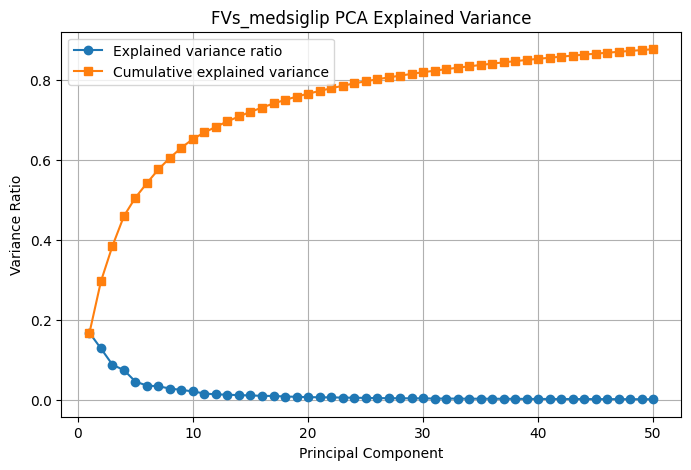

In [8]:
explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)

plt.figure(figsize=(8, 5))
plt.plot(range(1, n_components + 1), explained, marker="o", label="Explained variance ratio")
plt.plot(range(1, n_components + 1), cum_explained, marker="s", label="Cumulative explained variance")
plt.xlabel("Principal Component")
plt.ylabel("Variance Ratio")
plt.title(f"{model_name} PCA Explained Variance")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
pca_df = meta_df.copy()

for i in range(Z.shape[1]):
    pca_df[f"PC{i+1}"] = Z[:, i]

display(pca_df.head())

,patient_id,image_id,image_path,Overall quality,left_eye_DR_Level,right_eye_DR_Level,patient_DR_Level,Clarity,Field definition,Artifact,...,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49,PC50
0,1,1_l1,\regular-fundus-training\1\1_l1.jpg,0,0.0,NaN,0,8,8,4,...,-0.539592,1.494412,0.924922,1.765142,2.088180,-1.394080,0.153395,0.507603,1.284882,0.537035
1,1,1_l2,\regular-fundus-training\1\1_l2.jpg,0,0.0,NaN,0,8,8,0,...,0.017861,-0.155522,0.028570,2.230282,-0.854623,-0.462724,0.408873,-0.646712,1.731559,-1.445824
2,1,1_r1,\regular-fundus-training\1\1_r1.jpg,0,NaN,0.0,0,8,8,4,...,-0.049515,-0.622562,2.515025,-0.245626,-1.332191,-1.494487,0.301673,-1.296637,0.876496,-2.282738
3,1,1_r2,\regular-fundus-training\1\1_r2.jpg,0,NaN,0.0,0,10,8,0,...,-2.594752,-0.232852,0.524813,1.952866,-0.374533,-0.442085,-0.140440,0.488700,1.135891,-2.998279
4,2,2_l1,\regular-fundus-training\2\2_l1.jpg,0,2.0,NaN,2,10,8,6,...,0.398691,0.144278,-2.453766,1.302608,1.538555,0.307455,-0.939416,-1.167635,-1.182510,-0.423395


### DR label distribution

In [11]:
LABEL_COL = "eye_DR_Level"

print("Total rows:", len(meta_df))
print("Missing labels:", meta_df[LABEL_COL].isna().sum())

label_dist = (
    meta_df[LABEL_COL]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("DR_Level")
    .reset_index(name="count")
)

label_dist["ratio_%"] = (
    label_dist["count"] / label_dist["count"].sum() * 100
).round(2)

display(label_dist)

Total rows: 1189
Missing labels: 0


,DR_Level,count,ratio_%
0,0.0,532,44.74
1,1.0,139,11.69
2,2.0,232,19.51
3,3.0,214,18.00
4,4.0,72,6.06


In [12]:
for threshold in [0, 1, 2, 3]:
    y = (meta_df[LABEL_COL] > threshold).astype(int)

    print(f"DR > {threshold}:")
    print(y.value_counts().sort_index())
    print()

DR > 0:
eye_DR_Level
0    532
1    657
Name: count, dtype: int64

DR > 1:
eye_DR_Level
0    671
1    518
Name: count, dtype: int64

DR > 2:
eye_DR_Level
0    903
1    286
Name: count, dtype: int64

DR > 3:
eye_DR_Level
0    1117
1      72
Name: count, dtype: int64



PC1-PC50 DR level spearman

In [24]:
LABEL_COL = "eye_DR_Level"
N_PC = 50

spearman_df = analyze_all_pc_spearman(
    df=pca_df,
    label_col=LABEL_COL,
    n_pc=N_PC
)

,PC,n,spearman_rho,abs_rho,p_value
0,PC1,1189,-0.787509,0.787509,8.999141e-252
2,PC3,1189,-0.120237,0.120237,3.228357e-05
8,PC9,1189,0.116171,0.116171,5.939931e-05
4,PC5,1189,-0.091602,0.091602,1.567294e-03
7,PC8,1189,-0.059665,0.059665,3.968199e-02
5,PC6,1189,0.057047,0.057047,4.922814e-02
11,PC12,1189,0.056792,0.056792,5.024980e-02
3,PC4,1189,-0.055953,0.055953,5.375083e-02
30,PC31,1189,-0.055550,0.055550,5.550234e-02
42,PC43,1189,-0.054977,0.054977,5.807127e-02


,PC,label,n,spearman_rho,abs_rho,p_value
0,PC1,eye_DR_Level,1189,-0.787509,0.787509,8.999141e-252


,eye_DR_Level,count,mean,std,median,min,max
0,0.0,532,11.263342,8.527180,12.659557,-17.592566,26.164639
1,1.0,139,5.299660,7.327280,5.557725,-15.518842,22.430807
2,2.0,232,-11.314476,7.788920,-13.006645,-25.553719,13.291148
3,3.0,214,-14.860353,5.977955,-15.234951,-25.127960,-0.589164
4,4.0,72,-12.828849,6.028564,-14.393599,-23.055935,2.955026


<Figure size 700x400 with 0 Axes>

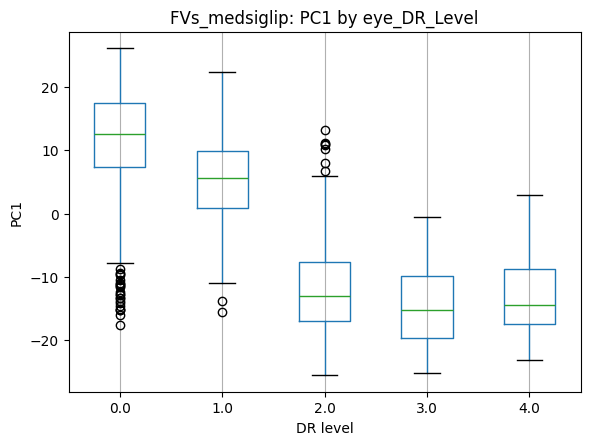

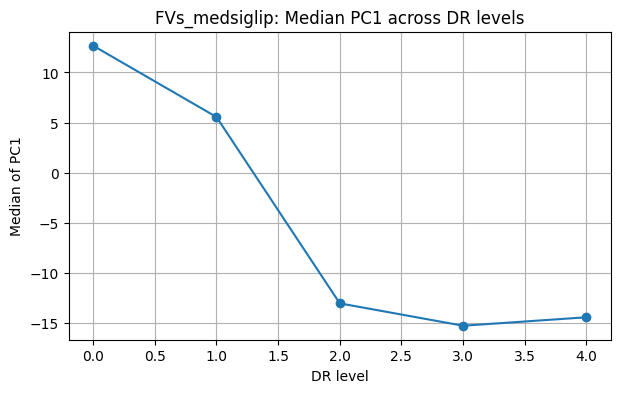

In [25]:
# PC1 と DR 重症度の単調関係を可視化

PC_COL = "PC1"
GRADE_COL = "eye_DR_Level"

tmp = pca_df[[PC_COL, GRADE_COL]].copy()
tmp[PC_COL] = pd.to_numeric(tmp[PC_COL], errors="coerce")
tmp[GRADE_COL] = pd.to_numeric(tmp[GRADE_COL], errors="coerce")
tmp = tmp.dropna()

# Spearman
rho, p_value = spearmanr(tmp[PC_COL], tmp[GRADE_COL])

result_df = pd.DataFrame([{
    "PC": PC_COL,
    "label": GRADE_COL,
    "n": len(tmp),
    "spearman_rho": rho,
    "abs_rho": abs(rho),
    "p_value": p_value
}])

display(result_df)

# 各DR levelの要約
dr_summary_df = (
    tmp.groupby(GRADE_COL)[PC_COL]
    .agg(["count", "mean", "std", "median", "min", "max"])
    .reset_index()
    .sort_values(GRADE_COL)
)

display(dr_summary_df)

# 箱ひげ図
plt.figure(figsize=(7, 4))
tmp.boxplot(column=PC_COL, by=GRADE_COL)
plt.suptitle("")
plt.title(f"{model_name}: {PC_COL} by {GRADE_COL}")
plt.xlabel("DR level")
plt.ylabel(PC_COL)
plt.grid(axis="y")
plt.show()

# 中央値の推移
plt.figure(figsize=(7, 4))
plt.plot(dr_summary_df[GRADE_COL], dr_summary_df["median"], marker="o")
plt.xlabel("DR level")
plt.ylabel(f"Median of {PC_COL}")
plt.title(f"{model_name}: Median {PC_COL} across DR levels")
plt.grid(True)
plt.show()

PC1 を DR level ごとに可視化したところ、DR 重症度の上昇に伴って PC1 の分布は全体として低下する傾向を示した。特に DR level 0–1 と 2–4 の間で分布の差が大きく、PC1 が DR 重症度に関連する特徴を強く反映していることが示唆された。一方で、DR level 3 と 4 の間では中央値の差は小さく、完全な単調変化ではなかった。

PC1 l r AUC

eye distribution:


,eye,count
0,l,594
1,r,595


,PC,factor,negative_label,positive_label,n,AUC_raw,AUC_direction_free,abs_AUC_minus_0.5,mean_PC_negative,mean_PC_positive,median_PC_negative,median_PC_positive
0,PC1,eye,l,r,1189,0.497739,0.502261,0.002261,0.042585,-0.042513,1.085639,1.550115


PC1 summary by eye:


,eye,count,mean,std,median,min,max
0,l,594,0.042585,14.105858,1.085639,-25.553719,26.164639
1,r,595,-0.042513,13.758000,1.550115,-25.127960,24.126062


<Figure size 600x400 with 0 Axes>

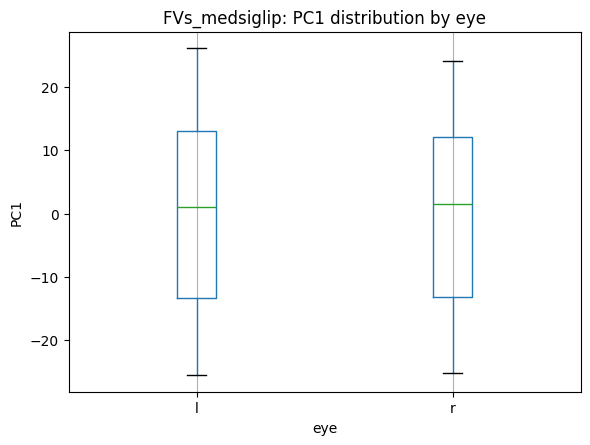

In [14]:
PC_COL = "PC1"
EYE_COL = "eye"

eye_auc_df, eye_summary_df = analyze_pc_binary_auc(
    df=pca_df,
    pc_col=PC_COL,
    factor_col=EYE_COL,
    value_map={"l": 0, "r": 1},
    model_name=model_name,
    factor_name="eye",
    negative_label="l",
    positive_label="r",
    preprocess_func=lambda s: s.astype(str).str.lower().str.strip(),
    xlabel="eye",
    title=f"{model_name}: {PC_COL} distribution by eye"
)

Overall quality distribution

Total rows: 1189
Missing Overall quality: 0
Unique Overall quality values:
[np.int64(0), np.int64(1)]
Unexpected scores: None


,Overall quality,count,ratio_%
0,0,620,52.14
1,1,569,47.86


Overall quality summary:


,count,mean,std,min,25%,50%,75%,max
Overall quality,1189.0,0.478553,0.49975,0.0,0.0,0.0,1.0,1.0


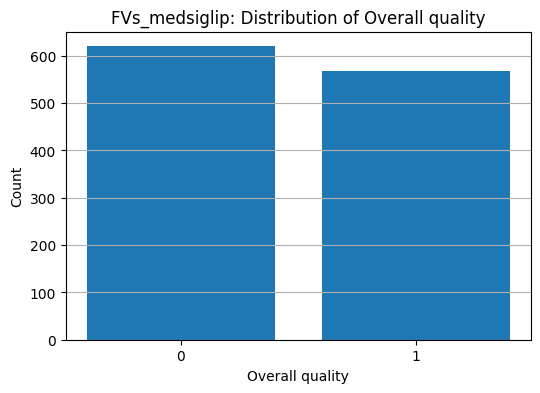

In [15]:
QUALITY_COL = "Overall quality"

quality_dist = display_ordered_distribution(
    df=pca_df,
    factor_col=QUALITY_COL,
    expected_scores={0, 1},
    model_name=model_name,
    xlabel="Overall quality",
    title=f"{model_name}: Distribution of Overall quality"
)

Overall quality AUC

Overall quality distribution:


,Overall quality,count
0,0,620
1,1,569


,PC,factor,negative_label,positive_label,n,AUC_raw,AUC_direction_free,abs_AUC_minus_0.5,mean_PC_negative,mean_PC_positive,median_PC_negative,median_PC_positive
0,PC1,Overall quality,0,1,1189,0.472544,0.527456,0.027456,0.600013,-0.653793,2.444187,0.292198


PC1 summary by Overall quality:


,Overall quality,count,mean,std,median,min,max
0,0,620,0.600013,13.098290,2.444187,-25.553719,24.526714
1,1,569,-0.653793,14.761187,0.292198,-25.127960,26.164639


<Figure size 600x400 with 0 Axes>

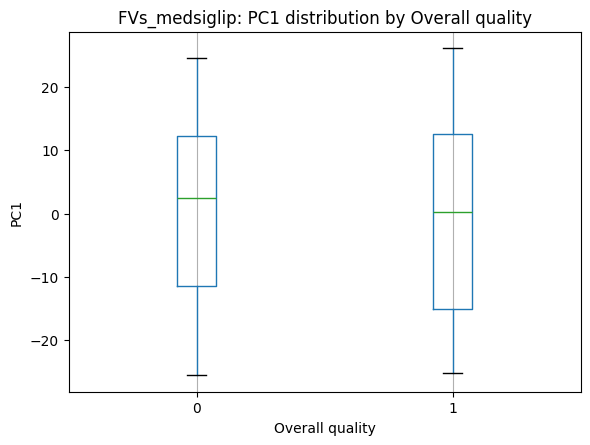

In [16]:
PC_COL = "PC1"
QUALITY_COL = "Overall quality"

quality_auc_df, quality_summary_df = analyze_pc_binary_auc(
    df=pca_df,
    pc_col=PC_COL,
    factor_col=QUALITY_COL,
    value_map={0: 0, 1: 1},
    model_name=model_name,
    factor_name="Overall quality",
    negative_label=0,
    positive_label=1,
    xlabel="Overall quality",
    title=f"{model_name}: {PC_COL} distribution by Overall quality"
)

view_no AUC

view_no distribution:


,view_no,count
0,1,594
1,2,595


,PC,factor,negative_label,positive_label,n,AUC_raw,AUC_direction_free,abs_AUC_minus_0.5,mean_PC_negative,mean_PC_positive,median_PC_negative,median_PC_positive
0,PC1,view_no,view1,view2,1189,0.515935,0.515935,0.015935,-0.365522,0.364908,0.380955,2.300424


PC1 summary by view_no:


,view_no,count,mean,std,median,min,max
0,1,594,-0.365522,13.249619,0.380955,-25.553719,25.422598
1,2,595,0.364908,14.574039,2.300424,-25.127960,26.164639


<Figure size 600x400 with 0 Axes>

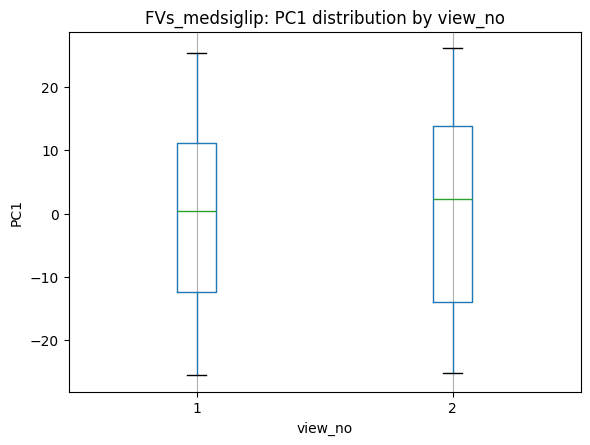

In [17]:
PC_COL = "PC1"
PATH_COL = "image_path"

pca_df["view_no"] = pca_df[PATH_COL].apply(extract_view_no)

view_auc_df, view_summary_df = analyze_pc_binary_auc(
    df=pca_df,
    pc_col=PC_COL,
    factor_col="view_no",
    value_map={1: 0, 2: 1},
    model_name=model_name,
    factor_name="view_no",
    negative_label="view1",
    positive_label="view2",
    xlabel="view_no",
    title=f"{model_name}: {PC_COL} distribution by view_no"
)

Clarity distribution

Total rows: 1189
Missing Clarity: 0
Unique Clarity values:
[np.int64(1), np.int64(4), np.int64(6), np.int64(8), np.int64(10)]
Unexpected scores: None


,Clarity,count,ratio_%
4,1,29,2.44
3,4,85,7.15
2,6,256,21.53
1,8,391,32.88
0,10,428,36.00


Clarity summary:


,count,mean,std,min,25%,50%,75%,max
Clarity,1189.0,7.832632,2.148465,1.0,6.0,8.0,10.0,10.0


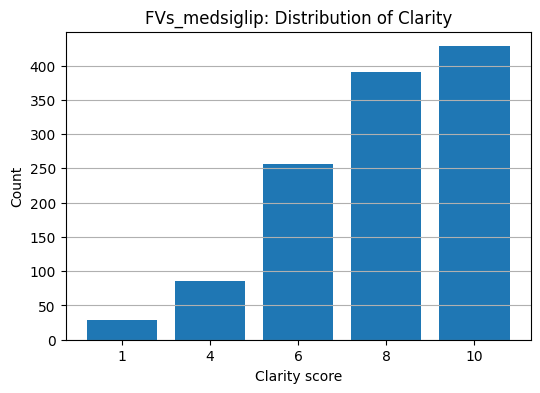

In [18]:
CLARITY_COL = "Clarity"

clarity_dist = display_ordered_distribution(
    df=pca_df,
    factor_col=CLARITY_COL,
    expected_scores={1, 4, 6, 8, 10},
    model_name=model_name,
    xlabel="Clarity score",
    title=f"{model_name}: Distribution of Clarity"
)

Clarity Spearman

,PC,factor,n,spearman_rho,abs_rho,p_value
0,PC1,Clarity,1189,-0.097083,0.097083,0.000802


,Clarity,count,mean,std,median,min,max
0,1,29,0.227219,11.105088,-0.605072,-21.380287,18.716547
1,4,85,-0.852758,12.661635,-3.601409,-22.028389,23.464945
2,6,256,1.745384,13.913807,3.642278,-23.430620,26.164639
3,8,391,1.385331,13.781146,3.816984,-23.186741,24.193617
4,10,428,-2.155578,14.232191,-1.938741,-25.553719,24.126062


<Figure size 700x400 with 0 Axes>

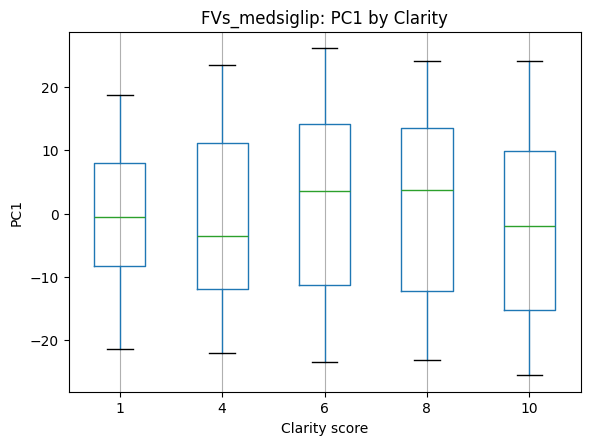

In [19]:
PC_COL = "PC1"
CLARITY_COL = "Clarity"

clarity_spearman_df, clarity_summary_df = analyze_pc_spearman_by_factor(
    df=pca_df,
    pc_col=PC_COL,
    factor_col=CLARITY_COL,
    model_name=model_name,
    xlabel="Clarity score",
    title=f"{model_name}: {PC_COL} by Clarity"
)

Artifact distribution

Total rows: 1189
Missing Artifact: 0
Unique Artifact values:
[np.int64(0), np.int64(1), np.int64(4), np.int64(6), np.int64(8), np.int64(10)]
Unexpected scores: None


,Artifact,count,ratio_%
0,0,592,49.79
4,1,45,3.78
1,4,238,20.02
2,6,146,12.28
3,8,131,11.02
5,10,37,3.11


Artifact summary:


,count,mean,std,min,25%,50%,75%,max
Artifact,1189.0,2.767872,3.189304,0.0,0.0,1.0,6.0,10.0


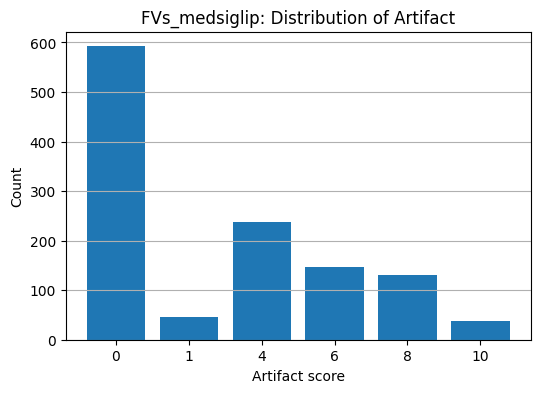

In [20]:
ARTIFACT_COL = "Artifact"

artifact_dist = display_ordered_distribution(
    df=pca_df,
    factor_col=ARTIFACT_COL,
    expected_scores={0, 1, 4, 6, 8, 10},
    model_name=model_name,
    xlabel="Artifact score",
    title=f"{model_name}: Distribution of Artifact"
)

Artifact Spearman

,PC,factor,n,spearman_rho,abs_rho,p_value
0,PC1,Artifact,1189,-0.135486,0.135486,0.000003


,Artifact,count,mean,std,median,min,max
0,0,592,2.031445,14.345150,5.193042,-25.127960,26.164639
1,1,45,3.288856,13.495730,7.699512,-21.807838,23.906040
2,4,238,-3.116056,13.678328,-6.147876,-25.553719,23.007038
3,6,146,-2.669828,12.844759,-4.983861,-23.283087,25.422598
4,8,131,-1.672510,12.578469,-3.863491,-22.325600,23.464945
5,10,37,-0.002677,12.150790,-0.605072,-23.430620,17.702631


<Figure size 700x400 with 0 Axes>

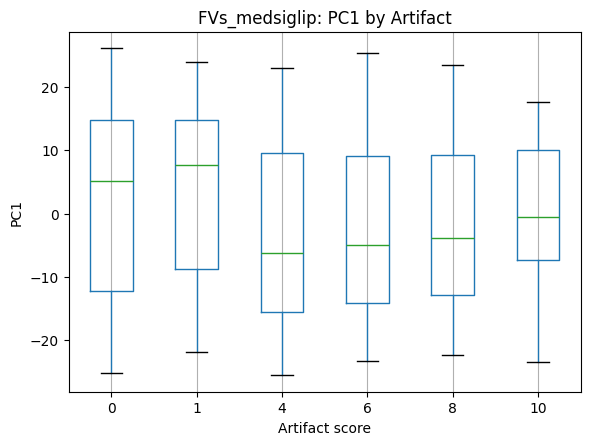

In [21]:
PC_COL = "PC1"
ARTIFACT_COL = "Artifact"

artifact_spearman_df, artifact_summary_df = analyze_pc_spearman_by_factor(
    df=pca_df,
    pc_col=PC_COL,
    factor_col=ARTIFACT_COL,
    model_name=model_name,
    xlabel="Artifact score",
    title=f"{model_name}: {PC_COL} by Artifact"
)

Field definition distribution

Total rows: 1189
Missing Field definition: 0
Unique Field definition values:
[np.int64(1), np.int64(4), np.int64(6), np.int64(8), np.int64(10)]
Unexpected scores: None


,Field definition,count,ratio_%
4,1,6,0.50
3,4,45,3.78
1,6,178,14.97
0,8,799,67.20
2,10,161,13.54


Field definition summary:


,count,mean,std,min,25%,50%,75%,max
Field definition,1189.0,7.784693,1.395906,1.0,8.0,8.0,8.0,10.0


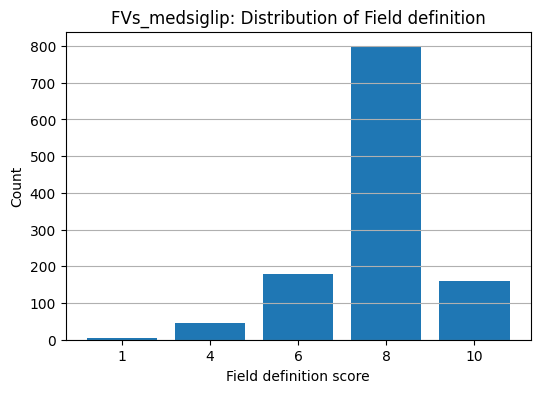

In [22]:
FIELD_COL = "Field definition"

field_dist = display_ordered_distribution(
    df=pca_df,
    factor_col=FIELD_COL,
    expected_scores={1, 4, 6, 8, 10},
    model_name=model_name,
    xlabel="Field definition score",
    title=f"{model_name}: Distribution of Field definition"
)

Field Spearman

,PC,factor,n,spearman_rho,abs_rho,p_value
0,PC1,Field definition,1189,0.094805,0.094805,0.001064


,Field definition,count,mean,std,median,min,max
0,1,6,2.034162,10.341793,4.092327,-10.771757,17.557945
1,4,45,-2.017670,11.799124,0.454125,-22.110058,19.161556
2,6,178,-5.531737,11.730518,-7.618398,-25.553719,22.996634
3,8,799,1.550359,14.058609,4.400739,-25.127960,26.164639
4,10,161,-1.090045,14.561264,-0.545344,-25.027676,23.744459


<Figure size 700x400 with 0 Axes>

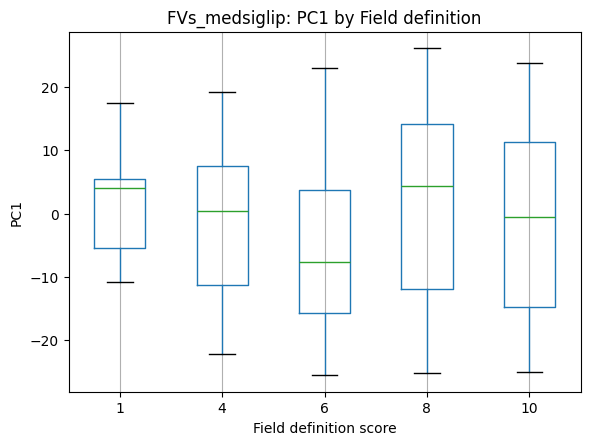

In [23]:
PC_COL = "PC1"
FIELD_COL = "Field definition"

field_spearman_df, field_summary_df = analyze_pc_spearman_by_factor(
    df=pca_df,
    pc_col=PC_COL,
    factor_col=FIELD_COL,
    model_name=model_name,
    xlabel="Field definition score",
    title=f"{model_name}: {PC_COL} by Field definition"
)

In [24]:
confound_summary_df = pd.concat([
    pd.DataFrame([{
        "factor": "eye",
        "method": "AUC",
        "metric": "AUC_direction_free",
        "value": eye_auc_df["AUC_direction_free"].iloc[0] if eye_auc_df is not None else np.nan,
        "effect_size": eye_auc_df["abs_AUC_minus_0.5"].iloc[0] if eye_auc_df is not None else np.nan
    }]),
    pd.DataFrame([{
        "factor": "Overall quality",
        "method": "AUC",
        "metric": "AUC_direction_free",
        "value": quality_auc_df["AUC_direction_free"].iloc[0] if quality_auc_df is not None else np.nan,
        "effect_size": quality_auc_df["abs_AUC_minus_0.5"].iloc[0] if quality_auc_df is not None else np.nan
    }]),
    pd.DataFrame([{
        "factor": "view_no",
        "method": "AUC",
        "metric": "AUC_direction_free",
        "value": view_auc_df["AUC_direction_free"].iloc[0] if view_auc_df is not None else np.nan,
        "effect_size": view_auc_df["abs_AUC_minus_0.5"].iloc[0] if view_auc_df is not None else np.nan
    }]),
    pd.DataFrame([{
        "factor": "Clarity",
        "method": "Spearman",
        "metric": "abs_rho",
        "value": clarity_spearman_df["spearman_rho"].iloc[0],
        "effect_size": clarity_spearman_df["abs_rho"].iloc[0]
    }]),
    pd.DataFrame([{
        "factor": "Artifact",
        "method": "Spearman",
        "metric": "abs_rho",
        "value": artifact_spearman_df["spearman_rho"].iloc[0],
        "effect_size": artifact_spearman_df["abs_rho"].iloc[0]
    }]),
    pd.DataFrame([{
        "factor": "Field definition",
        "method": "Spearman",
        "metric": "abs_rho",
        "value": field_spearman_df["spearman_rho"].iloc[0],
        "effect_size": field_spearman_df["abs_rho"].iloc[0]
    }]),
], ignore_index=True)

display(confound_summary_df)

,factor,method,metric,value,effect_size
0,eye,AUC,AUC_direction_free,0.502261,0.002261
1,Overall quality,AUC,AUC_direction_free,0.527456,0.027456
2,view_no,AUC,AUC_direction_free,0.515935,0.015935
3,Clarity,Spearman,abs_rho,-0.097083,0.097083
4,Artifact,Spearman,abs_rho,-0.135486,0.135486
5,Field definition,Spearman,abs_rho,0.094805,0.094805


### 解析結果のまとめ

本解析では、FVs_medsiglip の特徴ベクトルに対して PCA を適用し、各主成分と DR 重症度、および病変以外の要因との関係を画像単位で評価した。

PC1 は `eye_DR_Level` と強い単調関係を示した（Spearman's ρ = -0.788, n = 1189, p = 9.0 × 10^-252）。主成分の符号は任意であるため、負の方向そのものに臨床的意味を与えるべきではないが、相関係数の絶対値が大きいことから、PC1 は DR 重症度に関連する主要な変動軸を捉えている可能性が高い。

一方で、PC1 が病変以外の要因を反映している可能性を検討するため、左右眼、撮影視野番号、および画像品質関連指標との関係を確認した。その結果、左右眼の識別性能は AUC = 0.502、撮影視野番号の識別性能は AUC = 0.516、Overall quality の direction-free AUC は 0.527 であり、いずれもランダム分類に近い値であった。また、画像品質スコアとの単調関係も、Clarity（ρ = -0.097）、Artifact（ρ = -0.135）、Field definition（ρ = 0.095）と弱かった。

以上より、PC1 と DR 重症度との強い関連は、左右眼、撮影視野番号、または本解析で検討した画像品質指標によって主に説明されるものではないと考えられる。Artifact は画像品質関連指標の中では最も大きな関連を示したが、その効果量は小さく、PC1 の主要な要因というよりは、弱い交絡候補として扱うのが妥当である。

ただし、本解析は画像単位で行っており、同一患者または同一眼に由来する複数画像が含まれる可能性がある。そのため、p 値の解釈には注意が必要である。今後は、DR 重症度と各画像品質指標との関係を直接確認したうえで、同様の解析を他の基盤モデルにも拡張する必要がある。

### eye label distribution

Total rows: 1189
Valid eye rows: 1189
Invalid / missing eye rows: 0


,eye,count,ratio_%
0,l,594,49.96
1,r,595,50.04


eye_DR_Level,0.0,1.0,2.0,3.0,4.0,All
eye,,,,,,
l,256,77,123,96,42,594
r,276,62,109,118,30,595
All,532,139,232,214,72,1189


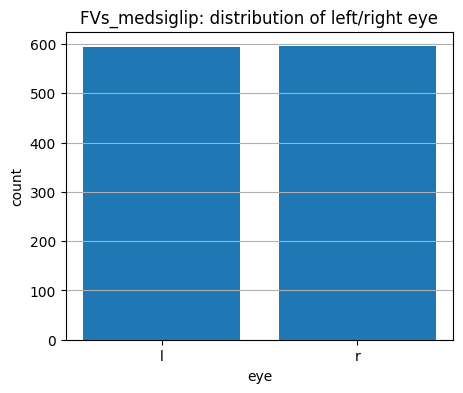

In [10]:
# PC2 解析前：左右眼ラベルの分布確認

EYE_COL = "eye"
LABEL_COL = "eye_DR_Level"

tmp_eye = pca_df[[EYE_COL, LABEL_COL]].copy()

# eye 表記を統一
tmp_eye[EYE_COL] = (
    tmp_eye[EYE_COL]
    .astype(str)
    .str.lower()
    .str.strip()
)

# 欠損・不明値の確認
valid_eye_labels = ["l", "r"]
tmp_eye["_eye_valid"] = tmp_eye[EYE_COL].isin(valid_eye_labels)

print("Total rows:", len(tmp_eye))
print("Valid eye rows:", tmp_eye["_eye_valid"].sum())
print("Invalid / missing eye rows:", (~tmp_eye["_eye_valid"]).sum())

if (~tmp_eye["_eye_valid"]).sum() > 0:
    print("Invalid / missing eye labels:")
    display(
        tmp_eye.loc[~tmp_eye["_eye_valid"], EYE_COL]
        .value_counts(dropna=False)
        .rename_axis("eye")
        .reset_index(name="count")
    )

# 左右眼の分布
eye_dist_df = (
    tmp_eye.loc[tmp_eye["_eye_valid"], EYE_COL]
    .value_counts()
    .reindex(valid_eye_labels)
    .rename_axis("eye")
    .reset_index(name="count")
)

eye_dist_df["ratio_%"] = (
    eye_dist_df["count"] / eye_dist_df["count"].sum() * 100
).round(2)

display(eye_dist_df)

# 左右眼 × DR level の分布
eye_dr_crosstab = pd.crosstab(
    tmp_eye.loc[tmp_eye["_eye_valid"], EYE_COL],
    tmp_eye.loc[tmp_eye["_eye_valid"], LABEL_COL],
    margins=True
)

display(eye_dr_crosstab)

# 棒グラフ
plt.figure(figsize=(5, 4))
plt.bar(eye_dist_df["eye"], eye_dist_df["count"])
plt.xlabel("eye")
plt.ylabel("count")
plt.title(f"{model_name}: distribution of left/right eye")
plt.grid(axis="y")
plt.show()

,PC,factor,negative_label,positive_label,n,"AUC_raw(l=0,r=1)",AUC_direction_free,abs_AUC_minus_0.5,mean_PC_l,mean_PC_r,median_PC_l,median_PC_r
0,PC2,eye,l,r,1189,0.961727,0.961727,0.461727,-9.909989,9.893334,-12.027864,11.519227


,eye,count,mean,std,median,min,max
0,l,594,-9.909989,6.965172,-12.027864,-21.829762,11.405498
1,r,595,9.893334,7.273373,11.519227,-12.850575,23.350195


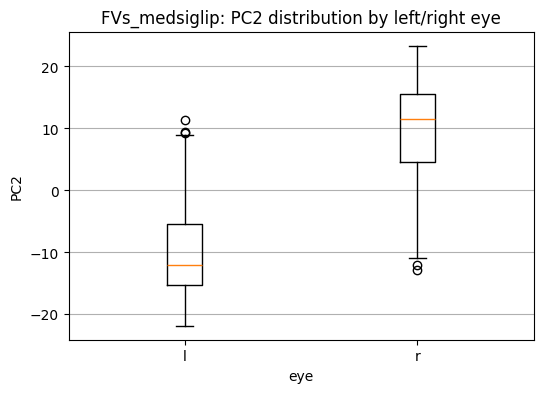

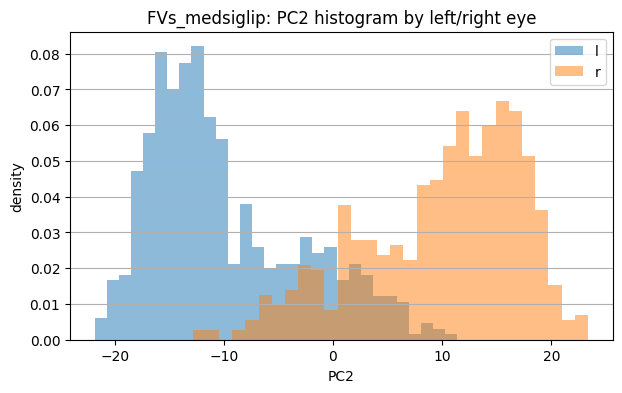

In [13]:
# PC2 と左右眼の関係：AUC解析

from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PC_COL = "PC2"
EYE_COL = "eye"

tmp = pca_df[[PC_COL, EYE_COL]].copy()

# eye 表記を統一
tmp[EYE_COL] = (
    tmp[EYE_COL]
    .astype(str)
    .str.lower()
    .str.strip()
)

# l / r のみ使用
tmp = tmp[tmp[EYE_COL].isin(["l", "r"])].dropna(subset=[PC_COL, EYE_COL]).copy()

# AUC用ラベル
# l = 0, r = 1 として固定
tmp["eye_binary"] = tmp[EYE_COL].map({"l": 0, "r": 1})

# AUC計算
auc_raw = roc_auc_score(tmp["eye_binary"], tmp[PC_COL])
auc_direction_free = max(auc_raw, 1 - auc_raw)

# 群ごとの統計
summary_df = (
    tmp.groupby(EYE_COL)[PC_COL]
    .agg(["count", "mean", "std", "median", "min", "max"])
    .reset_index()
)

auc_df = pd.DataFrame({
    "PC": [PC_COL],
    "factor": [EYE_COL],
    "negative_label": ["l"],
    "positive_label": ["r"],
    "n": [len(tmp)],
    "AUC_raw(l=0,r=1)": [auc_raw],
    "AUC_direction_free": [auc_direction_free],
    "abs_AUC_minus_0.5": [abs(auc_raw - 0.5)],
    "mean_PC_l": [tmp.loc[tmp[EYE_COL] == "l", PC_COL].mean()],
    "mean_PC_r": [tmp.loc[tmp[EYE_COL] == "r", PC_COL].mean()],
    "median_PC_l": [tmp.loc[tmp[EYE_COL] == "l", PC_COL].median()],
    "median_PC_r": [tmp.loc[tmp[EYE_COL] == "r", PC_COL].median()],
})

display(auc_df)
display(summary_df)

# 可視化 1: boxplot
left_values = tmp.loc[tmp[EYE_COL] == "l", PC_COL]
right_values = tmp.loc[tmp[EYE_COL] == "r", PC_COL]

plt.figure(figsize=(6, 4))
plt.boxplot([left_values, right_values], tick_labels=["l", "r"], showfliers=True)
plt.xlabel("eye")
plt.ylabel(PC_COL)
plt.title(f"{model_name}: {PC_COL} distribution by left/right eye")
plt.grid(axis="y")
plt.show()

# 可視化 2: histogram
plt.figure(figsize=(7, 4))
plt.hist(left_values, bins=30, alpha=0.5, label="l", density=True)
plt.hist(right_values, bins=30, alpha=0.5, label="r", density=True)
plt.xlabel(PC_COL)
plt.ylabel("density")
plt.title(f"{model_name}: {PC_COL} histogram by left/right eye")
plt.legend()
plt.grid(axis="y")
plt.show()

PC2は左右眼の違いを強く反映していたが、DR重症度との関連は限定的であった。このことから、PC2は病変関連表現ではなく、診断とは直接関係しない付帯情報を表す成分である可能性が示された。

distribution of Overall quality

In [17]:
QUALITY_COL = "Overall quality"

overall_quality_dist = (
    pca_df[QUALITY_COL]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis(QUALITY_COL)
    .reset_index(name="count")
)

overall_quality_dist["ratio_%"] = (
    overall_quality_dist["count"] / overall_quality_dist["count"].sum() * 100
).round(2)

display(overall_quality_dist)

,Overall quality,count,ratio_%
0,0,620,52.14
1,1,569,47.86


AUC rank

In [30]:
overall_quality_auc_rank_df = make_pc_auc_rank_table(
    df=pca_df,
    factor_col="Overall quality",
    n_pc=50,
    negative_label=0,
    positive_label=1
)

display(overall_quality_auc_rank_df)

,PC,factor,negative_label,positive_label,n,n_negative,n_positive,AUC_raw,AUC_direction_free,abs_AUC_minus_0.5,mean_PC_negative,mean_PC_positive,note
0,PC3,Overall quality,0,1,1189,620,569,0.657741,0.657741,0.157741,-2.615057,2.849448,
1,PC7,Overall quality,0,1,1189,620,569,0.618212,0.618212,0.118212,-1.308884,1.426200,
2,PC5,Overall quality,0,1,1189,620,569,0.394393,0.605607,0.105607,1.310001,-1.427418,
3,PC8,Overall quality,0,1,1189,620,569,0.593662,0.593662,0.093662,-0.959360,1.045349,
4,PC4,Overall quality,0,1,1189,620,569,0.582448,0.582448,0.082448,-1.250108,1.362157,
5,PC10,Overall quality,0,1,1189,620,569,0.420613,0.579387,0.079387,0.600572,-0.654402,
6,PC11,Overall quality,0,1,1189,620,569,0.425013,0.574987,0.074987,0.509227,-0.554869,
7,PC13,Overall quality,0,1,1189,620,569,0.428298,0.571702,0.071702,0.407725,-0.444270,
8,PC17,Overall quality,0,1,1189,620,569,0.432337,0.567663,0.067663,0.344755,-0.375656,
9,PC31,Overall quality,0,1,1189,620,569,0.436232,0.563768,0.063768,0.208051,-0.226698,


Total rows: 1189
Missing view_no: 0
Unique view_no values:
[np.int64(1), np.int64(2)]
Unexpected scores: None


,view_no,count,ratio_%
1,1,594,49.96
0,2,595,50.04


view_no summary:


,count,mean,std,min,25%,50%,75%,max
view_no,1189.0,1.500421,0.50021,1.0,1.0,2.0,2.0,2.0


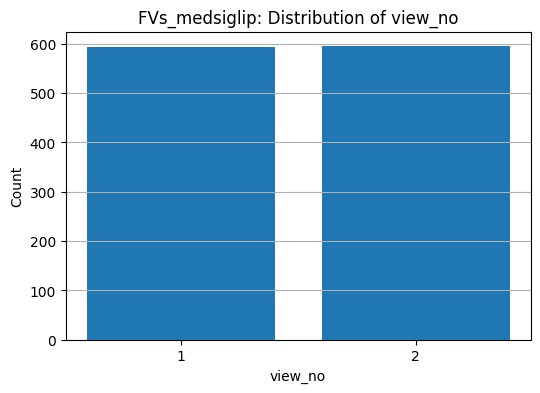

view_no,1,2,All
eye,,,
l,297,297,594
r,297,298,595
All,594,595,1189


,PC,factor,negative_label,positive_label,n,n_negative,n_positive,"AUC_raw(view1=0,view2=1)",AUC_direction_free,abs_AUC_minus_0.5,mean_PC_view1,mean_PC_view2,median_PC_view1,median_PC_view2
0,PC5,view_no,view1,view2,1189,594,595,0.188612,0.811388,0.311388,3.880123,-3.873601,3.870237,-3.861363
1,PC6,view_no,view1,view2,1189,594,595,0.316869,0.683131,0.183131,2.047907,-2.044466,2.423220,-1.714839
2,PC7,view_no,view1,view2,1189,594,595,0.380737,0.619263,0.119263,1.343360,-1.341102,0.870824,-1.822636
3,PC8,view_no,view1,view2,1189,594,595,0.396469,0.603531,0.103531,1.018389,-1.016677,0.938733,-1.483868
4,PC12,view_no,view1,view2,1189,594,595,0.597021,0.597021,0.097021,-0.620606,0.619563,-0.614652,0.793623
5,PC16,view_no,view1,view2,1189,594,595,0.572243,0.572243,0.072243,-0.432162,0.431436,-0.711950,0.011837
6,PC4,view_no,view1,view2,1189,594,595,0.572235,0.572235,0.072235,-1.225804,1.223744,-0.415835,1.474695
7,PC3,view_no,view1,view2,1189,594,595,0.568492,0.568492,0.068492,-1.438775,1.436357,-2.229752,-0.326716
8,PC11,view_no,view1,view2,1189,594,595,0.566525,0.566525,0.066525,-0.415954,0.415255,-0.925691,0.137028
9,PC9,view_no,view1,view2,1189,594,595,0.544294,0.544294,0.044294,-0.317933,0.317399,-0.125040,0.807706


In [22]:
# view_no の分布確認 + 各PCとのAUC rank表
# 既存の extract_view_no() を利用する

PATH_COL = "image_path"
VIEW_COL = "view_no"
N_PC = 50

# すでに view_no がある場合は再生成しない
if VIEW_COL not in pca_df.columns:
    pca_df[VIEW_COL] = pca_df[PATH_COL].apply(extract_view_no)

# ============================================================
# 1. view_no の分布確認
# ============================================================

view_no_dist = display_ordered_distribution(
    df=pca_df,
    factor_col=VIEW_COL,
    expected_scores={1, 2},
    model_name=model_name,
    xlabel="view_no",
    title=f"{model_name}: Distribution of view_no"
)

# eye × view_no も確認しておく
if "eye" in pca_df.columns:
    eye_view_crosstab = pd.crosstab(
        pca_df["eye"],
        pca_df[VIEW_COL],
        margins=True
    )
    display(eye_view_crosstab)

# ============================================================
# 2. 各PCと view_no のAUC rank表
# ============================================================

view_auc_rows = []

for i in range(1, N_PC + 1):
    pc = f"PC{i}"

    tmp = pca_df[[pc, VIEW_COL]].copy()
    tmp[pc] = pd.to_numeric(tmp[pc], errors="coerce")
    tmp[VIEW_COL] = pd.to_numeric(tmp[VIEW_COL], errors="coerce")

    tmp = tmp.dropna(subset=[pc, VIEW_COL]).copy()
    tmp = tmp[tmp[VIEW_COL].isin([1, 2])].copy()

    # view1 = 0, view2 = 1
    y_binary = tmp[VIEW_COL].map({1: 0, 2: 1}).astype(int)

    if y_binary.nunique() < 2:
        auc_raw = np.nan
        auc_direction_free = np.nan
    else:
        auc_raw = roc_auc_score(y_binary, tmp[pc])
        auc_direction_free = max(auc_raw, 1 - auc_raw)

    view_auc_rows.append({
        "PC": pc,
        "factor": VIEW_COL,
        "negative_label": "view1",
        "positive_label": "view2",
        "n": len(tmp),
        "n_negative": int((y_binary == 0).sum()),
        "n_positive": int((y_binary == 1).sum()),
        "AUC_raw(view1=0,view2=1)": auc_raw,
        "AUC_direction_free": auc_direction_free,
        "abs_AUC_minus_0.5": abs(auc_raw - 0.5) if pd.notna(auc_raw) else np.nan,
        "mean_PC_view1": tmp.loc[y_binary == 0, pc].mean(),
        "mean_PC_view2": tmp.loc[y_binary == 1, pc].mean(),
        "median_PC_view1": tmp.loc[y_binary == 0, pc].median(),
        "median_PC_view2": tmp.loc[y_binary == 1, pc].median(),
    })

view_no_auc_rank_df = (
    pd.DataFrame(view_auc_rows)
    .sort_values("AUC_direction_free", ascending=False)
    .reset_index(drop=True)
)

display(view_no_auc_rank_df.head(20))

Total rows: 1189
Missing Clarity: 0
Unique Clarity values:
[np.int64(1), np.int64(4), np.int64(6), np.int64(8), np.int64(10)]
Unexpected scores: None


,Clarity,count,ratio_%
4,1,29,2.44
3,4,85,7.15
2,6,256,21.53
1,8,391,32.88
0,10,428,36.00


Clarity summary:


,count,mean,std,min,25%,50%,75%,max
Clarity,1189.0,7.832632,2.148465,1.0,6.0,8.0,10.0,10.0


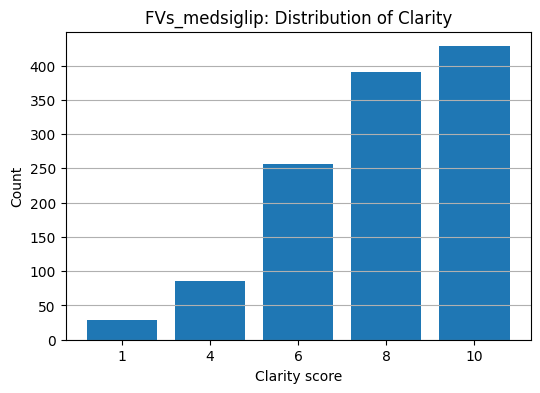

,PC,n,spearman_rho,abs_rho,p_value
2,PC3,1189,0.466898,0.466898,2.062211e-65
6,PC7,1189,0.366326,0.366326,4.542856e-39
3,PC4,1189,0.198928,0.198928,4.469144e-12
7,PC8,1189,0.188242,0.188242,6.041762e-11
5,PC6,1189,0.186323,0.186323,9.493842e-11
4,PC5,1189,-0.185748,0.185748,1.086184e-10
10,PC11,1189,-0.136986,0.136986,2.127316e-06
12,PC13,1189,-0.107251,0.107251,2.113735e-04
9,PC10,1189,-0.106450,0.106450,2.358288e-04
39,PC40,1189,-0.100667,0.100667,5.082493e-04


,PC,factor,n,spearman_rho,abs_rho,p_value
2,PC3,Clarity,1189,0.466898,0.466898,2.062211e-65
6,PC7,Clarity,1189,0.366326,0.366326,4.542856e-39
3,PC4,Clarity,1189,0.198928,0.198928,4.469144e-12
7,PC8,Clarity,1189,0.188242,0.188242,6.041762e-11
5,PC6,Clarity,1189,0.186323,0.186323,9.493842e-11
4,PC5,Clarity,1189,-0.185748,0.185748,1.086184e-10
10,PC11,Clarity,1189,-0.136986,0.136986,2.127316e-06
12,PC13,Clarity,1189,-0.107251,0.107251,2.113735e-04
9,PC10,Clarity,1189,-0.106450,0.106450,2.358288e-04
39,PC40,Clarity,1189,-0.100667,0.100667,5.082493e-04


Top PC for Clarity: PC3


,PC,factor,n,spearman_rho,abs_rho,p_value
0,PC3,Clarity,1189,0.466898,0.466898,2.062211e-65


,Clarity,count,mean,std,median,min,max
0,1,29,-6.516886,8.438160,-7.426209,-17.466297,18.100164
1,4,85,-7.784278,6.845926,-8.760668,-19.820807,17.529573
2,6,256,-5.183506,7.781496,-5.731212,-20.228542,26.076057
3,8,391,-0.310819,9.166173,-1.310560,-17.294127,25.994192
4,10,428,5.371872,9.830588,5.739455,-18.639292,29.697464


<Figure size 700x400 with 0 Axes>

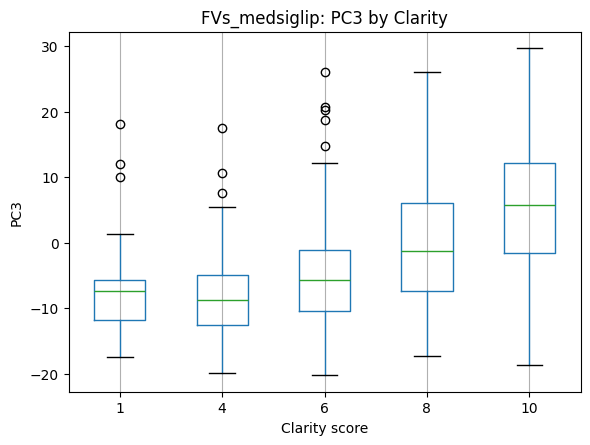

PC3 and DR severity:


,PC,checked_factor,n,spearman_rho,abs_rho,p_value
2,PC3,eye_DR_Level,1189,-0.120237,0.120237,0.000032


In [25]:
# Clarity の分布確認 + 各PCとの Spearman rank
# 既存の display_ordered_distribution(), analyze_all_pc_spearman(),
# analyze_pc_spearman_by_factor() を利用する

CLARITY_COL = "Clarity"
N_PC = 50

# ============================================================
# 1. Clarity の分布確認
# ============================================================

clarity_dist = display_ordered_distribution(
    df=pca_df,
    factor_col=CLARITY_COL,
    expected_scores={1, 4, 6, 8, 10},
    model_name=model_name,
    xlabel="Clarity score",
    title=f"{model_name}: Distribution of Clarity"
)

# ============================================================
# 2. 各PCと Clarity の Spearman rank表
# ============================================================

clarity_spearman_rank_df = analyze_all_pc_spearman(
    df=pca_df,
    label_col=CLARITY_COL,
    n_pc=N_PC,
    pc_prefix="PC"
)

# 表として後から見やすいように factor 列を追加
clarity_spearman_rank_df = clarity_spearman_rank_df.copy()
clarity_spearman_rank_df.insert(1, "factor", CLARITY_COL)

display(clarity_spearman_rank_df.head(20))

# ============================================================
# 3. Clarity と最も関連が強いPCを詳細確認
# ============================================================

top_clarity_pc = clarity_spearman_rank_df.iloc[0]["PC"]

print(f"Top PC for Clarity: {top_clarity_pc}")

clarity_top_result_df, clarity_top_summary_df = analyze_pc_spearman_by_factor(
    df=pca_df,
    pc_col=top_clarity_pc,
    factor_col=CLARITY_COL,
    model_name=model_name,
    xlabel="Clarity score",
    title=f"{model_name}: {top_clarity_pc} by Clarity"
)

# ============================================================
# 4. 参考：Clarity top PC が DR 軸かどうかを既存のDR Spearman結果で確認
#    すでに spearman_df が作成済みの場合のみ表示する
# ============================================================

if "spearman_df" in globals():
    dr_check_df = spearman_df.copy()
    dr_check_df = dr_check_df[dr_check_df["PC"] == top_clarity_pc].copy()
    dr_check_df.insert(1, "checked_factor", "eye_DR_Level")
    
    print(f"{top_clarity_pc} and DR severity:")
    display(dr_check_df)
else:
    print("spearman_df が見つかりません。必要であれば、先に PC1-PC50 と DR level の Spearman 解析セルを実行してください。")

In [26]:
# Clarity と DR 重症度の Spearman rank を確認
from scipy.stats import spearmanr
import pandas as pd

DR_COL = "eye_DR_Level"
CLARITY_COL = "Clarity"

tmp = pca_df[[CLARITY_COL, DR_COL]].dropna().copy()

rho, p = spearmanr(tmp[CLARITY_COL], tmp[DR_COL])

clarity_dr_corr_df = pd.DataFrame([{
    "factor": CLARITY_COL,
    "checked_factor": DR_COL,
    "n": len(tmp),
    "spearman_rho": rho,
    "abs_rho": abs(rho),
    "p_value": p
}])

display(clarity_dr_corr_df)

,factor,checked_factor,n,spearman_rho,abs_rho,p_value
0,Clarity,eye_DR_Level,1189,0.039137,0.039137,0.177455


Total rows: 1189
Missing Field definition: 0
Unique Field definition values:
[np.int64(1), np.int64(4), np.int64(6), np.int64(8), np.int64(10)]
Unexpected scores: None


,Field definition,count,ratio_%
4,1,6,0.50
3,4,45,3.78
1,6,178,14.97
0,8,799,67.20
2,10,161,13.54


Field definition summary:


,count,mean,std,min,25%,50%,75%,max
Field definition,1189.0,7.784693,1.395906,1.0,8.0,8.0,8.0,10.0


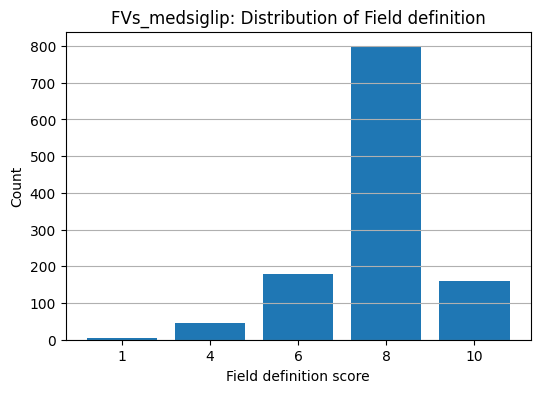

,PC,n,spearman_rho,abs_rho,p_value
4,PC5,1189,-0.401609,0.401609,2.645826e-47
2,PC3,1189,0.203226,0.203226,1.503323e-12
5,PC6,1189,-0.180480,0.180480,3.650842e-10
3,PC4,1189,0.124244,0.124244,1.736642e-05
17,PC18,1189,-0.107885,0.107885,1.937473e-04
32,PC33,1189,-0.096904,0.096904,8.204486e-04
0,PC1,1189,0.094805,0.094805,1.064130e-03
11,PC12,1189,0.090512,0.090512,1.783062e-03
18,PC19,1189,-0.080348,0.080348,5.569045e-03
20,PC21,1189,0.073029,0.073029,1.177190e-02


,PC,factor,n,spearman_rho,abs_rho,p_value
4,PC5,Field definition,1189,-0.401609,0.401609,2.645826e-47
2,PC3,Field definition,1189,0.203226,0.203226,1.503323e-12
5,PC6,Field definition,1189,-0.180480,0.180480,3.650842e-10
3,PC4,Field definition,1189,0.124244,0.124244,1.736642e-05
17,PC18,Field definition,1189,-0.107885,0.107885,1.937473e-04
32,PC33,Field definition,1189,-0.096904,0.096904,8.204486e-04
0,PC1,Field definition,1189,0.094805,0.094805,1.064130e-03
11,PC12,Field definition,1189,0.090512,0.090512,1.783062e-03
18,PC19,Field definition,1189,-0.080348,0.080348,5.569045e-03
20,PC21,Field definition,1189,0.073029,0.073029,1.177190e-02


Top PC for Field definition: PC5


,PC,factor,n,spearman_rho,abs_rho,p_value
0,PC5,Field definition,1189,-0.401609,0.401609,2.645826e-47


,Field definition,count,mean,std,median,min,max
0,1,6,3.871443,6.530213,3.158050,-4.286630,13.237418
1,4,45,2.521316,7.152963,3.500465,-15.294190,15.641230
2,6,178,5.706472,6.811412,6.201674,-14.633795,18.761349
3,8,799,-0.338022,6.640696,-0.696343,-18.591421,18.716019
4,10,161,-5.480498,6.254184,-5.930857,-18.370237,14.284243


<Figure size 700x400 with 0 Axes>

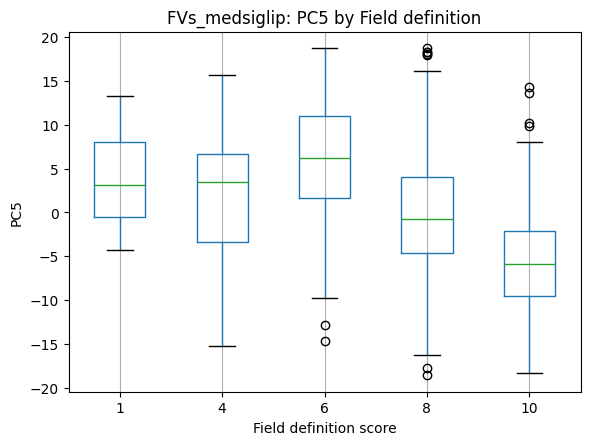

PC5 and DR severity:


,PC,checked_factor,n,spearman_rho,abs_rho,p_value
4,PC5,eye_DR_Level,1189,-0.091602,0.091602,0.001567


In [27]:
# Field definition の分布確認 + 各PCとの Spearman rank
# 既存の display_ordered_distribution(), analyze_all_pc_spearman(),
# analyze_pc_spearman_by_factor() を利用する

FIELD_COL = "Field definition"
N_PC = 50

# ============================================================
# 1. Field definition の分布確認
# ============================================================

field_dist = display_ordered_distribution(
    df=pca_df,
    factor_col=FIELD_COL,
    expected_scores={1, 4, 6, 8, 10},
    model_name=model_name,
    xlabel="Field definition score",
    title=f"{model_name}: Distribution of Field definition"
)

# ============================================================
# 2. 各PCと Field definition の Spearman rank表
# ============================================================

field_spearman_rank_df = analyze_all_pc_spearman(
    df=pca_df,
    label_col=FIELD_COL,
    n_pc=N_PC,
    pc_prefix="PC"
)

field_spearman_rank_df = field_spearman_rank_df.copy()
field_spearman_rank_df.insert(1, "factor", FIELD_COL)

display(field_spearman_rank_df.head(20))

# ============================================================
# 3. Field definition と最も関連が強いPCを詳細確認
# ============================================================

top_field_pc = field_spearman_rank_df.iloc[0]["PC"]

print(f"Top PC for Field definition: {top_field_pc}")

field_top_result_df, field_top_summary_df = analyze_pc_spearman_by_factor(
    df=pca_df,
    pc_col=top_field_pc,
    factor_col=FIELD_COL,
    model_name=model_name,
    xlabel="Field definition score",
    title=f"{model_name}: {top_field_pc} by Field definition"
)

# ============================================================
# 4. 参考：Field definition top PC が DR 軸かどうかを既存のDR Spearman結果で確認
# ============================================================

if "spearman_df" in globals():
    dr_check_df = spearman_df.copy()
    dr_check_df = dr_check_df[dr_check_df["PC"] == top_field_pc].copy()
    dr_check_df.insert(1, "checked_factor", "eye_DR_Level")

    print(f"{top_field_pc} and DR severity:")
    display(dr_check_df)
else:
    print("spearman_df が見つかりません。必要であれば、先に PC1-PC50 と DR level の Spearman 解析セルを実行してください。")

这个好像分不太开

Total rows: 1189
Missing Artifact: 0
Unique Artifact values:
[np.int64(0), np.int64(1), np.int64(4), np.int64(6), np.int64(8), np.int64(10)]
Unexpected scores: None


,Artifact,count,ratio_%
0,0,592,49.79
4,1,45,3.78
1,4,238,20.02
2,6,146,12.28
3,8,131,11.02
5,10,37,3.11


Artifact summary:


,count,mean,std,min,25%,50%,75%,max
Artifact,1189.0,2.767872,3.189304,0.0,0.0,1.0,6.0,10.0


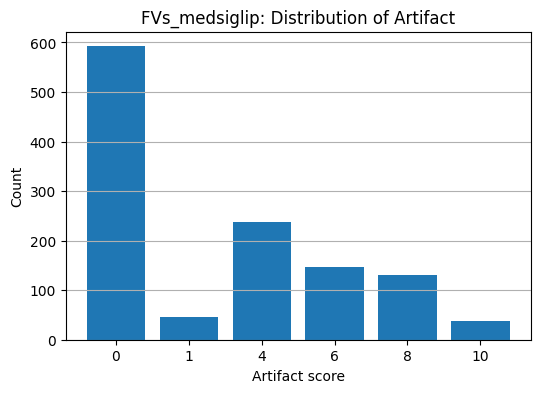

,PC,n,spearman_rho,abs_rho,p_value
4,PC5,1189,0.372877,0.372877,1.599977e-40
2,PC3,1189,-0.352623,0.352623,3.890039e-36
6,PC7,1189,-0.313665,0.313665,1.478045e-28
3,PC4,1189,-0.236884,0.236884,1.255625e-16
10,PC11,1189,0.211819,0.211819,1.581425e-13
16,PC17,1189,0.198201,0.198201,5.361256e-12
9,PC10,1189,0.168015,0.168015,5.580320e-09
12,PC13,1189,0.143559,0.143559,6.669964e-07
0,PC1,1189,-0.135486,0.135486,2.751636e-06
7,PC8,1189,-0.106254,0.106254,2.421845e-04


,PC,factor,n,spearman_rho,abs_rho,p_value
4,PC5,Artifact,1189,0.372877,0.372877,1.599977e-40
2,PC3,Artifact,1189,-0.352623,0.352623,3.890039e-36
6,PC7,Artifact,1189,-0.313665,0.313665,1.478045e-28
3,PC4,Artifact,1189,-0.236884,0.236884,1.255625e-16
10,PC11,Artifact,1189,0.211819,0.211819,1.581425e-13
16,PC17,Artifact,1189,0.198201,0.198201,5.361256e-12
9,PC10,Artifact,1189,0.168015,0.168015,5.580320e-09
12,PC13,Artifact,1189,0.143559,0.143559,6.669964e-07
0,PC1,Artifact,1189,-0.135486,0.135486,2.751636e-06
7,PC8,Artifact,1189,-0.106254,0.106254,2.421845e-04


Top PC for Artifact: PC5


,PC,factor,n,spearman_rho,abs_rho,p_value
0,PC5,Artifact,1189,0.372877,0.372877,1.599977e-40


,Artifact,count,mean,std,median,min,max
0,0,592,-2.666982,6.815448,-2.973165,-18.591421,16.740412
1,1,45,-0.930654,5.917382,-1.918820,-11.231026,13.454760
2,4,238,2.501554,6.860111,2.554673,-15.551062,18.716019
3,6,146,2.741342,6.788861,3.052447,-14.633795,18.761349
4,8,131,3.243124,6.692283,3.271775,-11.119422,18.292635
5,10,37,5.412924,5.952299,4.197336,-7.044404,18.112398


<Figure size 700x400 with 0 Axes>

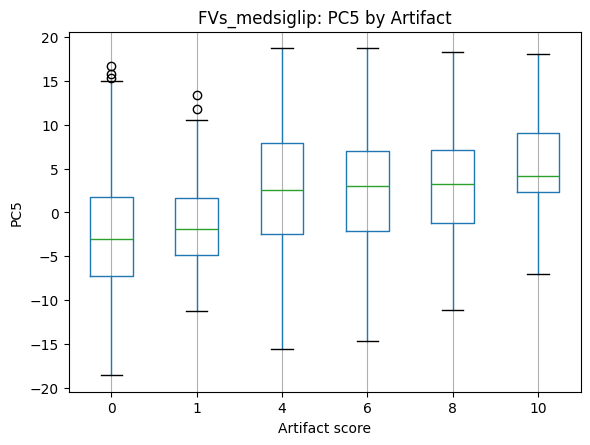

PC5 and DR severity:


,PC,checked_factor,n,spearman_rho,abs_rho,p_value
4,PC5,eye_DR_Level,1189,-0.091602,0.091602,0.001567


In [28]:
# Artifact の分布確認 + 各PCとの Spearman rank
# 既存の display_ordered_distribution(), analyze_all_pc_spearman(),
# analyze_pc_spearman_by_factor() を利用する

ARTIFACT_COL = "Artifact"
N_PC = 50

# ============================================================
# 1. Artifact の分布確認
# ============================================================

artifact_dist = display_ordered_distribution(
    df=pca_df,
    factor_col=ARTIFACT_COL,
    expected_scores={0, 1, 4, 6, 8, 10},
    model_name=model_name,
    xlabel="Artifact score",
    title=f"{model_name}: Distribution of Artifact"
)

# ============================================================
# 2. 各PCと Artifact の Spearman rank表
# ============================================================

artifact_spearman_rank_df = analyze_all_pc_spearman(
    df=pca_df,
    label_col=ARTIFACT_COL,
    n_pc=N_PC,
    pc_prefix="PC"
)

artifact_spearman_rank_df = artifact_spearman_rank_df.copy()
artifact_spearman_rank_df.insert(1, "factor", ARTIFACT_COL)

display(artifact_spearman_rank_df.head(20))

# ============================================================
# 3. Artifact と最も関連が強いPCを詳細確認
# ============================================================

top_artifact_pc = artifact_spearman_rank_df.iloc[0]["PC"]

print(f"Top PC for Artifact: {top_artifact_pc}")

artifact_top_result_df, artifact_top_summary_df = analyze_pc_spearman_by_factor(
    df=pca_df,
    pc_col=top_artifact_pc,
    factor_col=ARTIFACT_COL,
    model_name=model_name,
    xlabel="Artifact score",
    title=f"{model_name}: {top_artifact_pc} by Artifact"
)

# ============================================================
# 4. 参考：Artifact top PC が DR 軸かどうかを既存のDR Spearman結果で確認
# ============================================================

if "spearman_df" in globals():
    dr_check_df = spearman_df.copy()
    dr_check_df = dr_check_df[dr_check_df["PC"] == top_artifact_pc].copy()
    dr_check_df.insert(1, "checked_factor", "eye_DR_Level")

    print(f"{top_artifact_pc} and DR severity:")
    display(dr_check_df)
else:
    print("spearman_df が見つかりません。必要であれば、先に PC1-PC50 と DR level の Spearman 解析セルを実行してください。")

In [29]:
# 非病変因子同士の Spearman 相関を確認
from scipy.stats import spearmanr
import pandas as pd
import numpy as np

factor_cols = [
    "Clarity",
    "Field definition",
    "Artifact",
    "view_no",
    "eye_DR_Level",
]

rows = []

for i, col1 in enumerate(factor_cols):
    for col2 in factor_cols[i+1:]:
        tmp = pca_df[[col1, col2]].dropna()
        rho, p = spearmanr(tmp[col1], tmp[col2])
        rows.append({
            "factor_1": col1,
            "factor_2": col2,
            "n": len(tmp),
            "spearman_rho": rho,
            "abs_rho": abs(rho),
            "p_value": p
        })

factor_corr_df = pd.DataFrame(rows).sort_values("abs_rho", ascending=False)
display(factor_corr_df)

,factor_1,factor_2,n,spearman_rho,abs_rho,p_value
1,Clarity,Artifact,1189,-0.567877,0.567877,1.820750e-102
5,Field definition,view_no,1189,0.386035,0.386035,1.521215e-43
4,Field definition,Artifact,1189,-0.218027,0.218027,2.922626e-14
7,Artifact,view_no,1189,-0.185777,0.185777,1.078714e-10
0,Clarity,Field definition,1189,0.151625,0.151625,1.494581e-07
6,Field definition,eye_DR_Level,1189,-0.082738,0.082738,4.305675e-03
8,Artifact,eye_DR_Level,1189,0.071299,0.071299,1.392963e-02
3,Clarity,eye_DR_Level,1189,0.039137,0.039137,1.774553e-01
2,Clarity,view_no,1189,0.014968,0.014968,6.061229e-01
9,view_no,eye_DR_Level,1189,0.000979,0.000979,9.731023e-01


factor,view_no,Overall quality,eye
PC,,,
PC1,0.015935,0.027456,0.002261
PC2,0.012339,0.050663,0.461727
PC3,0.068492,0.157741,0.011702
PC4,0.072235,0.082448,0.022168
PC5,0.311388,0.105607,0.018343
PC6,0.183131,0.054714,0.002453
PC7,0.119263,0.118212,0.006907
PC8,0.103531,0.093662,0.003576
PC9,0.044294,0.024361,0.023541


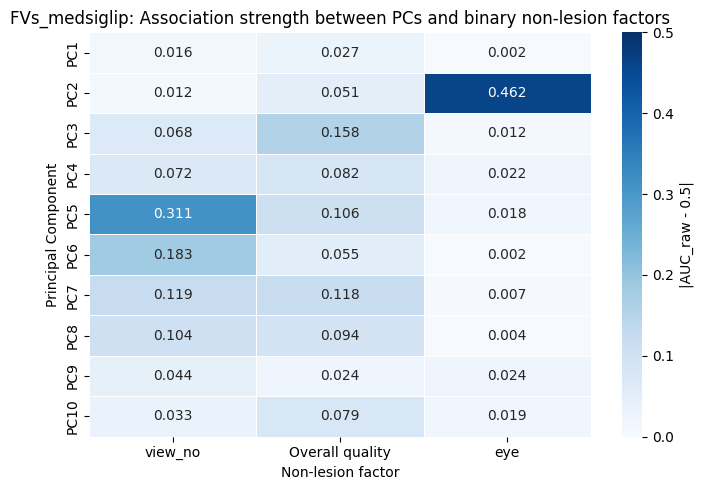

In [31]:
# ============================================================
# Heatmap: PC1-PC10 と二値非病変因子の AUC strength
# 使用指標: abs_AUC_minus_0.5
# 対象因子: view_no / Overall quality / eye
# ============================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

N_PC_SHOW = 10
pc_order = [f"PC{i}" for i in range(1, N_PC_SHOW + 1)]

# ------------------------------------------------------------
# 1. eye の AUC rank 表を作成
#    make_pc_auc_rank_table は前に定義済みのものを使う
# ------------------------------------------------------------

# eye 表記を安定させる
pca_df["_eye_norm"] = (
    pca_df["eye"]
    .astype(str)
    .str.lower()
    .str.strip()
)

eye_auc_rank_df = make_pc_auc_rank_table(
    df=pca_df,
    factor_col="_eye_norm",
    n_pc=50,
    negative_label="l",
    positive_label="r"
)

eye_auc_rank_df["factor"] = "eye"


# ------------------------------------------------------------
# 2. Overall quality の AUC rank 表
#    すでに overall_quality_auc_rank_df があればそれを使う
# ------------------------------------------------------------

overall_quality_auc_rank_df = make_pc_auc_rank_table(
    df=pca_df,
    factor_col="Overall quality",
    n_pc=50,
    negative_label=0,
    positive_label=1
)

overall_quality_auc_rank_df["factor"] = "Overall quality"


# ------------------------------------------------------------
# 3. view_no の AUC rank 表
#    view_no がなければ image_path から作成
# ------------------------------------------------------------

PATH_COL = "image_path"
VIEW_COL = "view_no"

if VIEW_COL not in pca_df.columns:
    pca_df[VIEW_COL] = pca_df[PATH_COL].apply(extract_view_no)

view_no_auc_rank_df = make_pc_auc_rank_table(
    df=pca_df,
    factor_col=VIEW_COL,
    n_pc=50,
    negative_label=1,
    positive_label=2
)

view_no_auc_rank_df["factor"] = "view_no"


# ------------------------------------------------------------
# 4. 3つのAUC rank表を結合
# ------------------------------------------------------------

binary_auc_strength_df = pd.concat(
    [
        view_no_auc_rank_df,
        overall_quality_auc_rank_df,
        eye_auc_rank_df
    ],
    ignore_index=True
)

# 表示順を固定
factor_order = ["view_no", "Overall quality", "eye"]

auc_strength_matrix = (
    binary_auc_strength_df
    .pivot(index="PC", columns="factor", values="abs_AUC_minus_0.5")
    .reindex(index=pc_order, columns=factor_order)
)

display(auc_strength_matrix)


# ------------------------------------------------------------
# 5. Heatmap
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

sns.heatmap(
    auc_strength_matrix,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    vmin=0.0,
    vmax=0.5,
    linewidths=0.5,
    cbar_kws={"label": "|AUC_raw - 0.5|"}
)

plt.title(f"{model_name}: Association strength between PCs and binary non-lesion factors")
plt.xlabel("Non-lesion factor")
plt.ylabel("Principal Component")
plt.tight_layout()
plt.show()

factor,Clarity,Field definition,Artifact,eye_DR_Level
PC,,,,
PC1,0.097083,0.094805,0.135486,0.787509
PC2,0.049894,0.065330,0.067383,0.001229
PC3,0.466898,0.203226,0.352623,0.120237
PC4,0.198928,0.124244,0.236884,0.055953
PC5,0.185748,0.401609,0.372877,0.091602
PC6,0.186323,0.180480,0.071773,0.057047
PC7,0.366326,0.054187,0.313665,0.043258
PC8,0.188242,0.058575,0.106254,0.059665
PC9,0.051477,0.010625,0.096150,0.116171


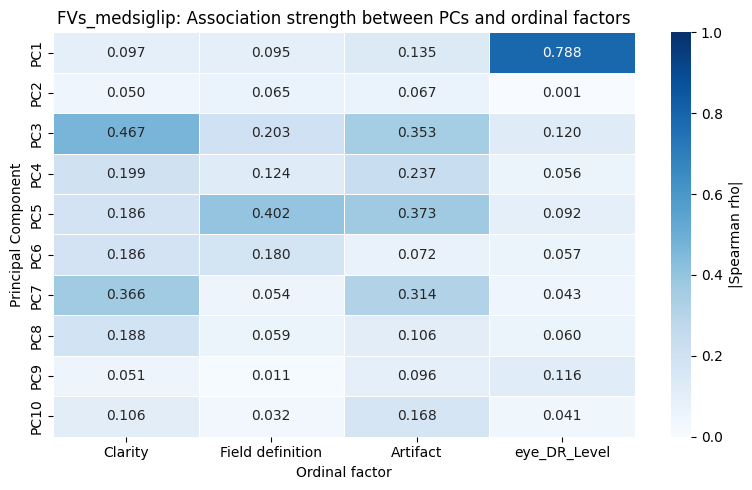

In [32]:
# ============================================================
# Heatmap: PC1-PC10 と有序因子の Spearman correlation strength
# 使用指標: abs_spearman_rho = |Spearman rho|
# 対象因子: Clarity / Field definition / Artifact / eye_DR_Level
# ============================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

N_PC_SHOW = 10
pc_order = [f"PC{i}" for i in range(1, N_PC_SHOW + 1)]

ordinal_factors = [
    "Clarity",
    "Field definition",
    "Artifact",
    "eye_DR_Level"
]

rows = []

for pc in pc_order:
    for factor in ordinal_factors:
        if pc not in pca_df.columns or factor not in pca_df.columns:
            rows.append({
                "PC": pc,
                "factor": factor,
                "n": 0,
                "spearman_rho": np.nan,
                "spearman_p": np.nan,
                "abs_spearman_rho": np.nan,
                "note": "column not found"
            })
            continue

        tmp = pca_df[[pc, factor]].copy()

        tmp[pc] = pd.to_numeric(tmp[pc], errors="coerce")
        tmp[factor] = pd.to_numeric(tmp[factor], errors="coerce")
        tmp = tmp.dropna()

        if len(tmp) < 3 or tmp[pc].nunique() < 2 or tmp[factor].nunique() < 2:
            rho = np.nan
            p_value = np.nan
            note = "not enough valid variation"
        else:
            rho, p_value = spearmanr(tmp[pc], tmp[factor])
            note = ""

        rows.append({
            "PC": pc,
            "factor": factor,
            "n": len(tmp),
            "spearman_rho": rho,
            "spearman_p": p_value,
            "abs_spearman_rho": abs(rho) if pd.notna(rho) else np.nan,
            "note": note
        })

spearman_factor_df = pd.DataFrame(rows)

# abs_spearman_rho の行列
abs_spearman_matrix = (
    spearman_factor_df
    .pivot(index="PC", columns="factor", values="abs_spearman_rho")
    .reindex(index=pc_order, columns=ordinal_factors)
)

display(abs_spearman_matrix)

# ------------------------------------------------------------
# Heatmap
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.heatmap(
    abs_spearman_matrix,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    vmin=0.0,
    vmax=1.0,
    linewidths=0.5,
    cbar_kws={"label": "|Spearman rho|"}
)

title_prefix = f"{model_name}: " if "model_name" in globals() else ""

plt.title(title_prefix + "Association strength between PCs and ordinal factors")
plt.xlabel("Ordinal factor")
plt.ylabel("Principal Component")
plt.tight_layout()
plt.show()